In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import pyproj
import matplotlib.pyplot as plt
import movingpandas as mpd
import contextily as ctx
from shapely import from_wkt
from datetime import datetime, timedelta

In [2]:
### Importing and displaying the data ###

gps_points = pd.read_csv("data/tartu_smart_bike_march_15_2021.csv")
gps_points.head()

,Unnamed: 0,route_code,userID,cyclenumber,latitude,longitude,coord_date,coord_time,geometry
0,261207,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369943,26.767472,2021-03-15,06:01,POINT (26.767471666666665 58.369943333333325)
1,261208,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369882,26.767293,2021-03-15,06:01,POINT (26.76729333333333 58.36988166666666)
2,261209,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369782,26.767263,2021-03-15,06:01,POINT (26.76726333333333 58.36978166666666)
3,261210,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369650,26.767368,2021-03-15,06:01,POINT (26.767368333333334 58.36965)
4,261211,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369515,26.767475,2021-03-15,06:01,POINT (26.767475 58.369515)


In [3]:
### Creating geometry type objects ###

gps_points["geometry"] = gps_points["geometry"].apply(from_wkt)

##districts["geometry"] = districts["geometry"].apply(from_wkt)

In [4]:
gps_points["geometry"]

0        POINT (26.767471666666665 58.369943333333325)
1          POINT (26.76729333333333 58.36988166666666)
2          POINT (26.76726333333333 58.36978166666666)
3                  POINT (26.767368333333334 58.36965)
4                          POINT (26.767475 58.369515)
                             ...                      
23859                       POINT (26.726895 58.35085)
23860              POINT (26.726885 58.35102166666666)
23861                        POINT (26.72688 58.35119)
23862     POINT (26.72686333333333 58.351353333333336)
23863             POINT (26.726841666666665 58.351505)
Name: geometry, Length: 23864, dtype: object

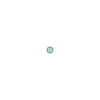

In [5]:
gps_points.loc[1]["geometry"]

In [6]:
gps_points = gpd.GeoDataFrame(gps_points)
gps_points
##gdf_districts = gpd.GeoDataFrame(districts)
##gdf_districts

,Unnamed: 0,route_code,userID,cyclenumber,latitude,longitude,coord_date,coord_time,geometry
0,261207,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369943,26.767472,2021-03-15,06:01,POINT (26.76747 58.36994)
1,261208,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369882,26.767293,2021-03-15,06:01,POINT (26.76729 58.36988)
2,261209,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369782,26.767263,2021-03-15,06:01,POINT (26.76726 58.36978)
3,261210,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369650,26.767368,2021-03-15,06:01,POINT (26.76737 58.36965)
4,261211,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369515,26.767475,2021-03-15,06:01,POINT (26.76748 58.36951)
...,...,...,...,...,...,...,...,...,...
23859,286110,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.350850,26.726895,2021-03-15,23:59,POINT (26.72689 58.35085)
23860,286111,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351022,26.726885,2021-03-15,23:59,POINT (26.72688 58.35102)
23861,286112,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351190,26.726880,2021-03-15,23:59,POINT (26.72688 58.35119)
23862,286113,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351353,26.726863,2021-03-15,23:59,POINT (26.72686 58.35135)


<Axes: >

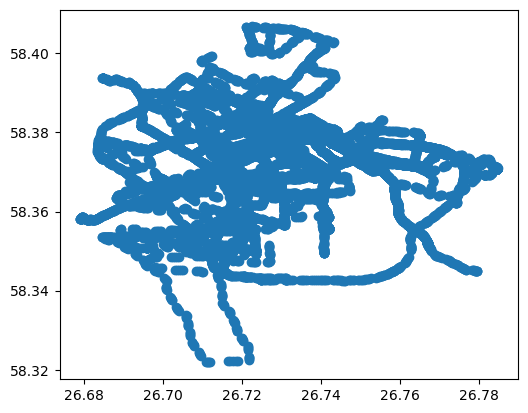

In [7]:
gps_points.plot()

In [8]:
gps_points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23864 entries, 0 to 23863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Unnamed: 0   23864 non-null  int64   
 1   route_code   23864 non-null  int64   
 2   userID       23864 non-null  object  
 3   cyclenumber  23864 non-null  int64   
 4   latitude     23864 non-null  float64 
 5   longitude    23864 non-null  float64 
 6   coord_date   23864 non-null  object  
 7   coord_time   23864 non-null  object  
 8   geometry     23864 non-null  geometry
dtypes: float64(2), geometry(1), int64(3), object(3)
memory usage: 1.6+ MB


In [9]:
gps_points.describe()

,Unnamed: 0,route_code,cyclenumber,latitude,longitude
count,23864.000000,2.386400e+04,23864.000000,23864.000000,23864.000000
mean,273154.001634,1.615814e+12,2672.447368,58.372915,26.727542
std,6903.472985,1.309548e+07,76.302743,0.010918,0.020243
min,261207.000000,1.615777e+12,2544.000000,58.321842,26.679148
25%,267180.750000,1.615807e+12,2611.000000,58.367071,26.715035
50%,273150.500000,1.615816e+12,2665.000000,58.374276,26.725912
75%,279118.250000,1.615824e+12,2743.000000,58.379237,26.739799
max,286114.000000,1.615842e+12,2795.000000,58.406810,26.784635


In [10]:
crs_gps = pyproj.CRS.from_epsg('4326') # WGS84 Mercator (degrees)
crs_web = pyproj.CRS.from_epsg('3857') # Pseudo-Mercator (meters)
crs_est = pyproj.CRS.from_epsg('3301') # Estonian Coordinate System

In [11]:
##Task 2
gps_points = gps_points.set_crs(crs_gps)

C:\Users\sonia\micromamba\envs\geopython2023\lib\site-packages\contextily\tile.py:581: UserWarning: The inferred zoom level of 30 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


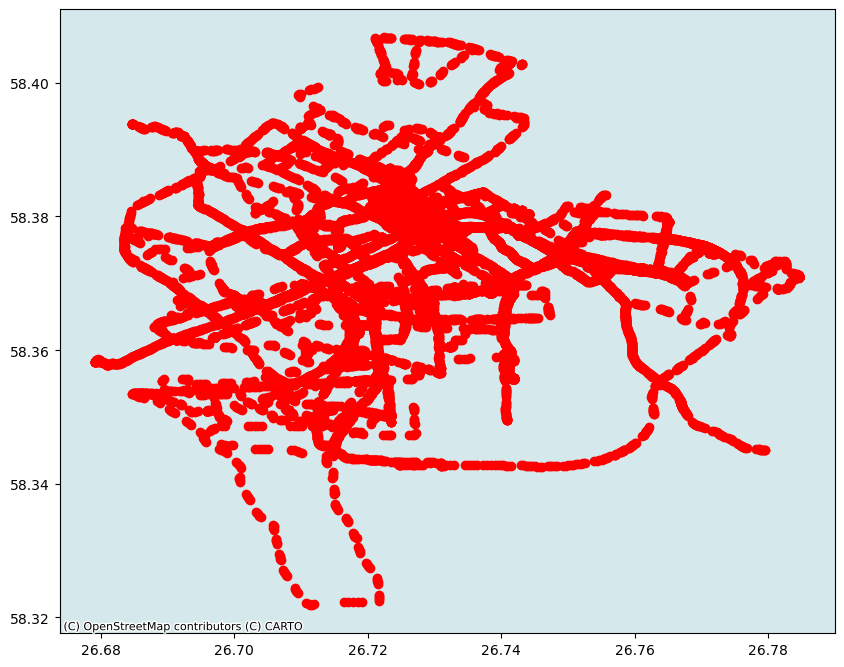

In [12]:
fig,ax = plt.subplots(1,1, figsize=(10,10))
gps_points.plot(ax=ax, color="red")
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)

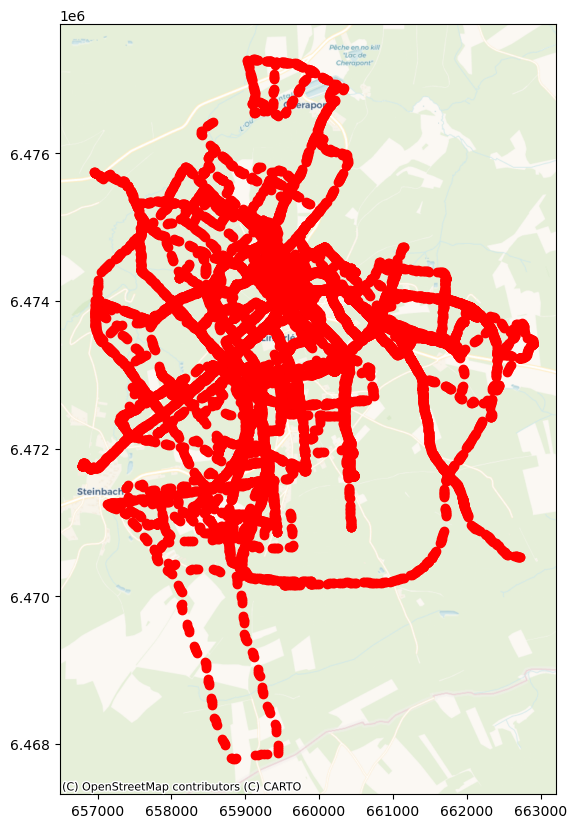

In [13]:
### Change the CRS and plot the data ###
### Change the CRS and plot the data ###

fig,ax = plt.subplots(1,1, figsize=(10,10))
gps_points = gps_points.to_crs(crs_est)
gps_points.plot(ax=ax, color="red")
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
#ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)
#ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik)

In [14]:
gps_points.crs

<Projected CRS: EPSG:3301>
Name: Estonian Coordinate System of 1997
Axis Info [cartesian]:
- X[north]: Northing (metre)
- Y[east]: Easting (metre)
Area of Use:
- name: Estonia - onshore and offshore.
- bounds: (20.37, 57.52, 28.2, 60.0)
Coordinate Operation:
- name: Estonian National Grid
- method: Lambert Conic Conformal (2SP)
Datum: Estonia 1997
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [15]:
### Calculate the distance between the first and last point of the dataset without changing CRS ###
distance = (gps_points.geometry.iloc[0].distance(gps_points.geometry.iloc[-1]))/1000
print("Distance between the first and last point in km:", distance)

Distance between the first and last point in km: 3.1421916552985967


In [16]:
##Changing crs it back to original
gps_points = gps_points.to_crs(crs_gps)

In [17]:
##exercise 3
### Create a time column with datetime values ###
gps_points['time'] = pd.to_datetime(gps_points['coord_date'] + ' ' + gps_points['coord_time'])
gps_points

,Unnamed: 0,route_code,userID,cyclenumber,latitude,longitude,coord_date,coord_time,geometry,time
0,261207,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369943,26.767472,2021-03-15,06:01,POINT (26.76747 58.36994),2021-03-15 06:01:00
1,261208,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369882,26.767293,2021-03-15,06:01,POINT (26.76729 58.36988),2021-03-15 06:01:00
2,261209,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369782,26.767263,2021-03-15,06:01,POINT (26.76726 58.36978),2021-03-15 06:01:00
3,261210,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369650,26.767368,2021-03-15,06:01,POINT (26.76737 58.36965),2021-03-15 06:01:00
4,261211,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369515,26.767475,2021-03-15,06:01,POINT (26.76748 58.36951),2021-03-15 06:01:00
...,...,...,...,...,...,...,...,...,...,...
23859,286110,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.350850,26.726895,2021-03-15,23:59,POINT (26.72689 58.35085),2021-03-15 23:59:00
23860,286111,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351022,26.726885,2021-03-15,23:59,POINT (26.72688 58.35102),2021-03-15 23:59:00
23861,286112,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351190,26.726880,2021-03-15,23:59,POINT (26.72688 58.35119),2021-03-15 23:59:00
23862,286113,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351353,26.726863,2021-03-15,23:59,POINT (26.72686 58.35135),2021-03-15 23:59:00


In [18]:
# MovingPandas needs the time to be the index column
gps_points = gps_points.set_index("time")

In [19]:
### Create a collection of trajectories based on the GPS points ###

minimum_length = 100
collection = mpd.TrajectoryCollection(gps_points, 'route_code', min_length=minimum_length)

In [20]:
print(collection)

TrajectoryCollection with 316 trajectories


<Axes: >

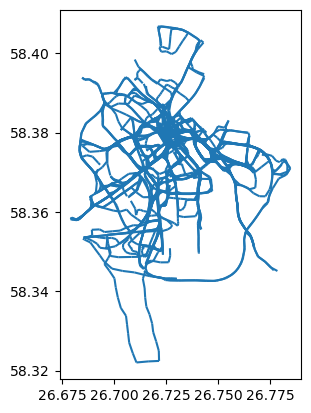

In [21]:
collection.plot()

In [22]:
collection.describe()

AttributeError: 'TrajectoryCollection' object has no attribute 'describe'

In [ ]:
##how many trajectories make up our collection?
##TrajectoryCollection with 229 trajectories

In [ ]:
#exercise 3
example_trajectory = collection.trajectories[6]

In [ ]:
example_trajectory

In [ ]:
#Duration (2021-03-15 22:13:00 to 2021-03-15 23:59:00


In [ ]:
#Length is around 66km

In [ ]:
#plotting using hvplot
example_trajectory.plot()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
example_trajectory.plot(ax=ax, color="red")
#gps_points.plot(ax=ax, color="red")
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
#ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()

In [ ]:
### Add speed to the trajectory ###
for trajectory in collection.trajectories:
    # Calculate speed
    trajectory.add_speed(overwrite=True)
    
    # Determine direction of movement
    trajectory.add_direction(overwrite=True)
    
    # Let's first check only the first trajectory (i.e. stop iteration after first run)
    break

In [ ]:
trajectory.df.head()

In [ ]:
### Plot the trajectory using speed attribute ###


fig, ax = plt.subplots(figsize=(10, 10))
trajectory.plot(ax=ax, column= 'speed')

ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
plt.show()

In [ ]:
#Exercise 4 - Aggregating trajectories
# Aggregate trajectories
agg = mpd.TrajectoryCollectionAggregator(collection, min_distance=500, max_distance=2000, min_stop_duration=timedelta(minutes=10))

# Get flows and clusters
flows = agg.get_flows_gdf()
clusters = agg.get_clusters_gdf()

In [ ]:
flows.head()

In [ ]:
clusters.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
clusters.plot(ax=ax)
flows.plot(ax=ax)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
plt.show()

In [ ]:
#### Feedback



###**How long did it take for you to finish these tasks? What was the toughest part?**
###IT took me 3 hours plotting using hv plot was difficult